# Week 13 — Visualization in Python

This notebook mirrors the four HTML examples but in the Python ecosystem most of you will use for your own research. Five short sections:

1. Load and clean a messy CSV with **pandas**
2. Time series with **matplotlib**
3. Distributions and relationships with **seaborn**
4. Interactive plots with **plotly.express**
5. Networks with **networkx** + matplotlib
6. Saving paper-ready figures (PDF/SVG)

If any import below fails, install with:
```
pip install pandas matplotlib seaborn plotly networkx
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import networkx as nx
import json

sns.set_theme(style='whitegrid', context='talk')

## 1. Load and clean a messy CSV

Real data is rarely clean. `corona_tweets_raw.csv` was generated with three common defects:
- mixed timestamp formats (`2020-02-27 06:00:00` vs `2/27/20 6:00`)
- missing values in `tweet_count` and `avg_sentiment`
- a few duplicate rows
- inconsistent hashtag capitalization

Cleaning it up is **half the work** of any visualization.

In [2]:
raw = pd.read_csv('data/corona_tweets_raw.csv')
print(raw.shape)
raw.head()

(125, 4)


,timestamp,hashtag,tweet_count,avg_sentiment
0,2020-02-27 16:30:00,#stayhome,30.0,0.175
1,2/27/20 15:00,#wuhan,37.0,-0.322
2,2/27/20 11:00,#pandemic,44.0,-0.090
3,2/27/20 15:00,#corona,93.0,-0.398
4,2/27/20 15:30,#corona,91.0,-0.212


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      125 non-null    str    
 1   hashtag        125 non-null    str    
 2   tweet_count    116 non-null    float64
 3   avg_sentiment  120 non-null    float64
dtypes: float64(2), str(2)
memory usage: 4.0 KB


In [4]:
# Parse the mixed timestamp formats. errors='coerce' turns any unparseable value into NaT,
# which we can then drop. format='mixed' lets pandas try multiple formats per row.
raw['timestamp'] = pd.to_datetime(raw['timestamp'], format='mixed', errors='coerce')

# Normalize hashtag capitalization
raw['hashtag'] = raw['hashtag'].str.lower()

# Drop duplicates and rows with missing critical fields
df = (raw
      .drop_duplicates()
      .dropna(subset=['timestamp', 'tweet_count', 'avg_sentiment'])
      .sort_values('timestamp')
      .reset_index(drop=True))

df['tweet_count'] = df['tweet_count'].astype(int)
print(f'{len(raw)} raw rows -> {len(df)} clean rows')
df.head()

125 raw rows -> 106 clean rows


,timestamp,hashtag,tweet_count,avg_sentiment
0,2020-02-27 06:00:00,#covid19,91,-0.116
1,2020-02-27 06:00:00,#wuhan,50,-0.625
2,2020-02-27 06:00:00,#corona,111,-0.267
3,2020-02-27 06:00:00,#pandemic,38,-0.215
4,2020-02-27 06:00:00,#stayhome,33,0.071


## 2. Time series with matplotlib

The matplotlib equivalent of `ex1.html`: one line per hashtag.

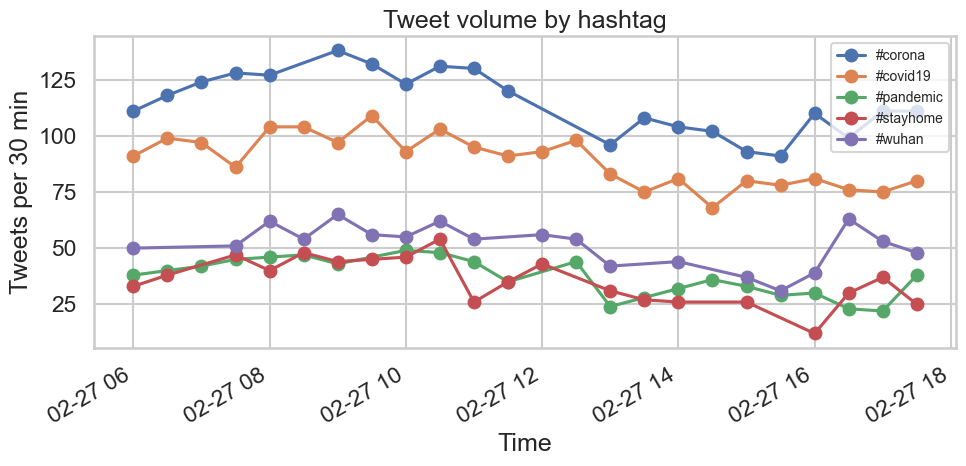

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for hashtag, group in df.groupby('hashtag'):
    ax.plot(group['timestamp'], group['tweet_count'], marker='o', label=hashtag)

ax.set_xlabel('Time')
ax.set_ylabel('Tweets per 30 min')
ax.set_title('Tweet volume by hashtag')
ax.legend(loc='upper right', fontsize=10)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3. Distributions and relationships with seaborn

The Python equivalent of `ex2.html`. Seaborn handles statistical layers like CI bands automatically.

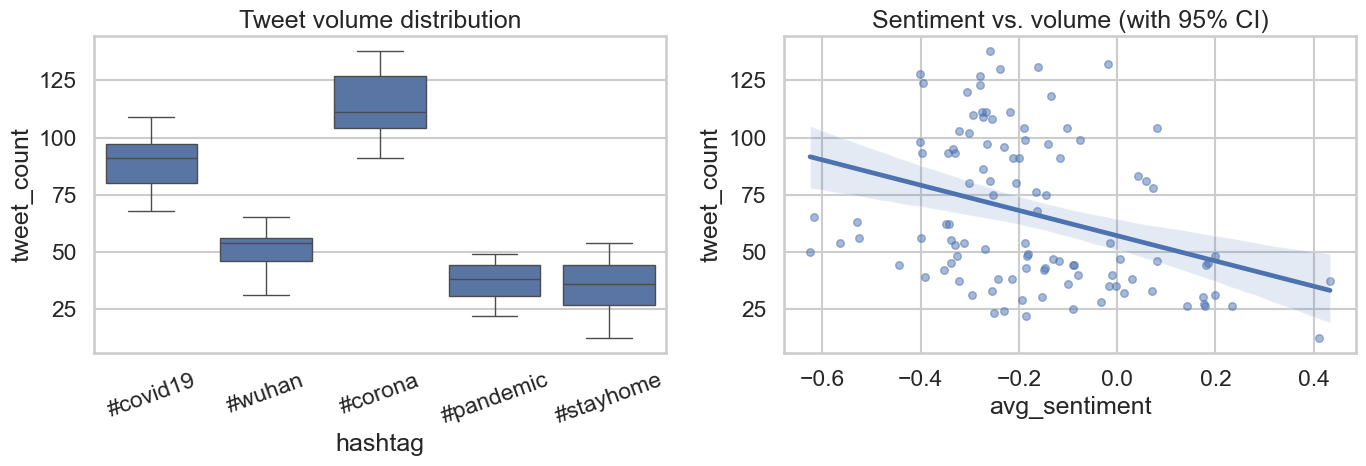

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: tweet count distribution per hashtag
sns.boxplot(data=df, x='hashtag', y='tweet_count', ax=axes[0])
axes[0].set_title('Tweet volume distribution')
axes[0].tick_params(axis='x', rotation=20)

# Regression with 95% CI band
sns.regplot(data=df, x='avg_sentiment', y='tweet_count',
            scatter_kws={'alpha': 0.5, 's': 30}, ax=axes[1])
axes[1].set_title('Sentiment vs. volume (with 95% CI)')

plt.tight_layout()
plt.show()

In [7]:
# Pearson correlation, for context
df[['tweet_count', 'avg_sentiment']].corr()

,tweet_count,avg_sentiment
tweet_count,1.000000,-0.337325
avg_sentiment,-0.337325,1.000000


## 4. Interactive plots with plotly.express

Same time series as section 2, but interactive — hover, zoom, toggle traces. Plotly Express is the high-level API; one line of code per plot.

In [8]:
fig = px.line(df, x='timestamp', y='tweet_count', color='hashtag',
              markers=True, title='Tweet volume by hashtag')
fig.show()

In [9]:
fig = px.box(df, x='hashtag', y='tweet_count',
             title='Tweet count distribution per hashtag', points='outliers')
fig.show()

## 5. Networks with networkx

The Python equivalent of `d3.html`. NetworkX builds the graph; matplotlib draws it. NetworkX is what you'd actually compute on (centrality, communities) before visualizing.

In [10]:
with open('data/twitter_network.json') as f:
    graph = json.load(f)

G = nx.Graph()
for n in graph['nodes']:
    G.add_node(n['id'], name=n['name'], degree=n['degree'])
for e in graph['links']:
    G.add_edge(e['source'], e['target'])

print(f'{G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

59 nodes, 58 edges


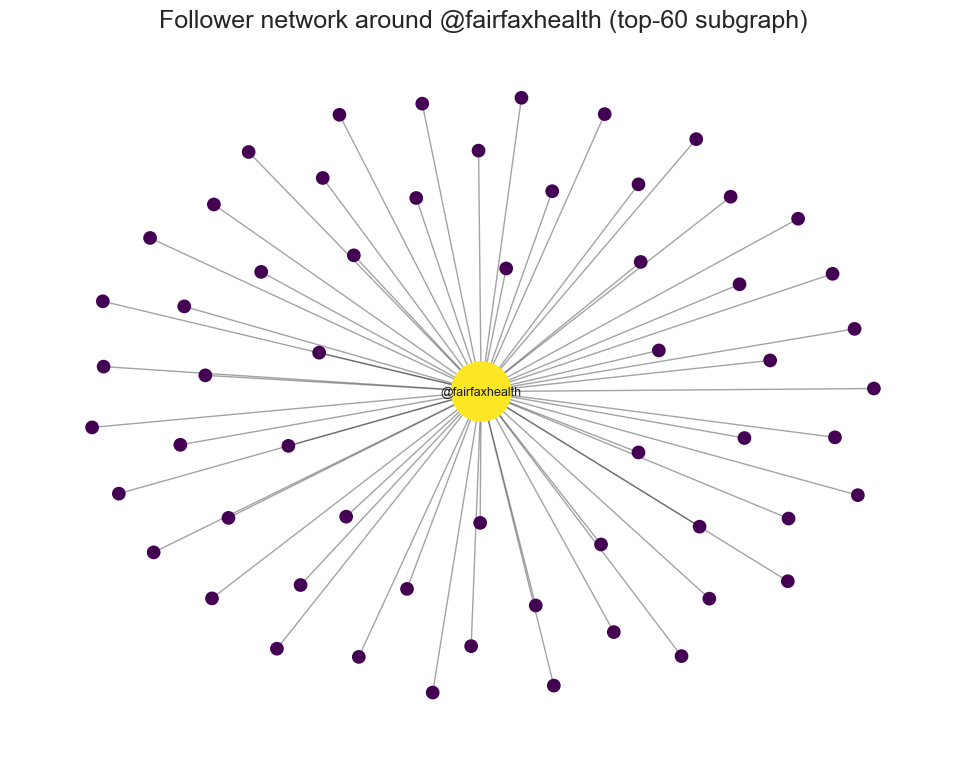

In [11]:
# Layout, then draw. Spring layout = force-directed, similar to D3's forceSimulation.
pos = nx.spring_layout(G, seed=42, k=0.3)

degrees = dict(G.degree())
node_sizes = [40 + 30 * degrees[n] for n in G.nodes]

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=list(degrees.values()),
                       cmap='viridis', ax=ax)

# Label only the high-degree hubs
labels = {n: '@' + G.nodes[n]['name'] for n, d in degrees.items() if d >= 3}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)

ax.set_title('Follower network around @fairfaxhealth (top-60 subgraph)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Saving paper-ready figures

For papers, save vector formats (PDF or SVG) — they scale without pixelating. Use a higher DPI for raster (PNG). Set the font once globally so all figures match.

Plotly figures can be exported with `fig.write_image('out.pdf')` (requires `kaleido`).

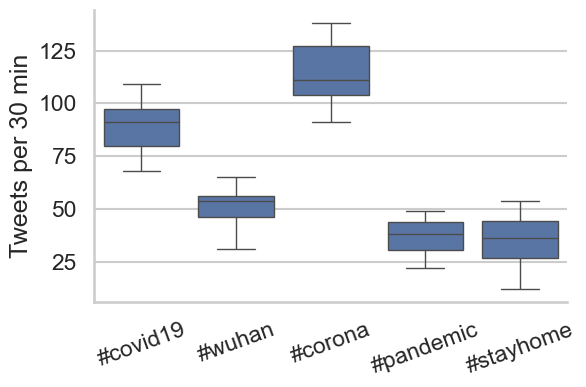

Saved: tweet_volume_box.pdf, tweet_volume_box.png


In [12]:
# Make a publication-style figure: larger fonts, no top/right spines, tight layout.
with plt.rc_context({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
}):
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.boxplot(data=df, x='hashtag', y='tweet_count', ax=ax)
    ax.set_xlabel('')
    ax.set_ylabel('Tweets per 30 min')
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()

    # PDF for LaTeX inclusion, PNG@300dpi as a fallback
    fig.savefig('tweet_volume_box.pdf')
    fig.savefig('tweet_volume_box.png', dpi=300)
    plt.show()

print('Saved: tweet_volume_box.pdf, tweet_volume_box.png')

---
## When to use what

| Goal | Tool |
|---|---|
| Static figures for a paper | matplotlib + seaborn |
| Quick exploration in a notebook | seaborn or `plotly.express` |
| Interactive dashboard or web demo | Plotly (HTML) or D3 |
| Networks (analysis + viz) | networkx + matplotlib; for big graphs, [Gephi](https://gephi.org/) |
| Geospatial | `geopandas`, `folium`, or `kepler.gl` |

**Color tip**: avoid red/green for categorical data — ~5% of men can't distinguish them. `viridis`, `cividis`, and the default seaborn palette are color-blind safe.
